In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load data
df = pd.read_csv('../../hey_banco_complete_features.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 71 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   15025 non-null  object 
 1   edad                      15025 non-null  int64  
 2   sexo                      15025 non-null  object 
 3   estado                    14593 non-null  object 
 4   ciudad                    14593 non-null  object 
 5   nivel_educativo           15025 non-null  object 
 6   ocupacion                 15025 non-null  object 
 7   ingreso_mensual_mxn       15025 non-null  int64  
 8   antiguedad_dias           15025 non-null  int64  
 9   es_hey_pro_x              15025 non-null  bool   
 10  nomina_domiciliada        15025 non-null  bool   
 11  canal_apertura            15025 non-null  object 
 12  score_buro                15025 non-null  int64  
 13  dias_desde_ultimo_login   15025 non-null  int64  
 14  prefer

# Axis 1: Financial Risk Profile
Expected clusters: Conservative, Moderate, Aggressive, Distressed

KMeans Silhouette: 0.18833683771614174


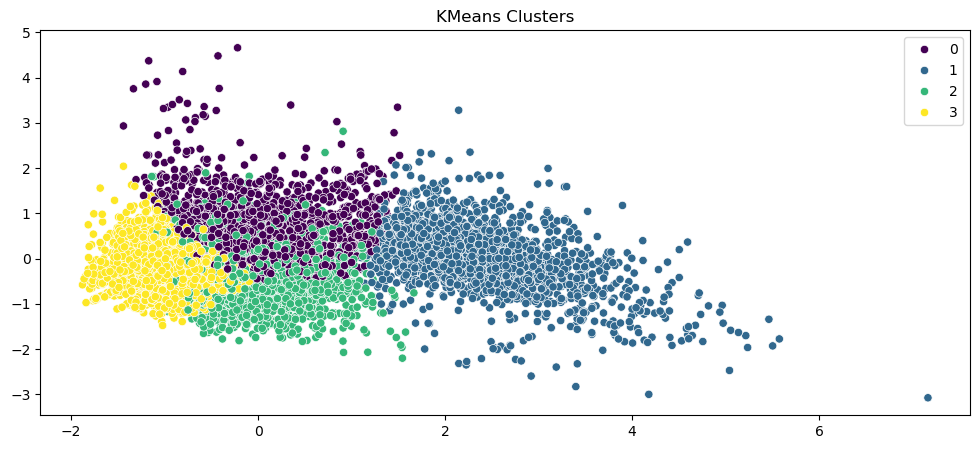

KMeans labels:
kmeans_label
Conservative    4040
Aggressive      3049
Moderate        2218
Distressed      1663
Name: count, dtype: int64


In [9]:
# Select features
axis1_features = ['score_buro', 'avg_credit_utilization', 'failed_txn_rate', 'atypical_txn_rate', 'dispute_rate', 'has_insurance', 'secured_card_flag']
df_axis1 = df[axis1_features]

# Drop NaN after encoding
df_axis1 = df_axis1.dropna()

# Scale
scaler = RobustScaler()
X_axis1 = scaler.fit_transform(df_axis1)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_axis1)
print('KMeans Silhouette:', silhouette_score(X_axis1, kmeans_labels))

# Visualize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_axis1)
plt.figure(figsize=(12,5))
plt.subplot(1,1,1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='viridis')
plt.title('KMeans Clusters')
plt.show()

# Assign labels
cluster_means = df_axis1.groupby(kmeans_labels).mean()
# Risk score: higher values indicate higher risk (Distressed)
risk_score = (cluster_means['avg_credit_utilization'] + cluster_means['failed_txn_rate'] + 
              cluster_means['atypical_txn_rate'] + cluster_means['dispute_rate'] - 
              cluster_means['score_buro'] - cluster_means['has_insurance'] - 
              cluster_means['secured_card_flag'])
cluster_risk = risk_score.sort_values()
labels = ['Conservative', 'Moderate', 'Aggressive', 'Distressed']
cluster_to_label = {old: new for old, new in zip(cluster_risk.index, labels)}
df_axis1['kmeans_label'] = [cluster_to_label[c] for c in kmeans_labels]
print('KMeans labels:')
print(df_axis1['kmeans_label'].value_counts())

## Axis 2: Income & Wealth Tier
Expected clusters: Entry, Growing, Established, Affluent

/tmp/ipykernel_33660/926451324.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_axis2['income_tier'] = df_axis2['income_tier'].map({'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4})


KMeans Silhouette: 0.5700488858584309


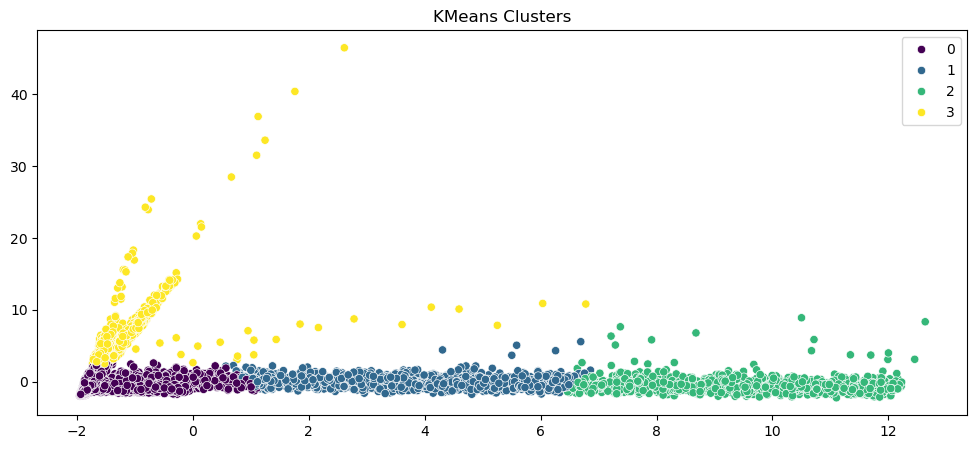

KMeans labels:
kmeans_label
Entry          7598
Growing        1232
Established    1079
Affluent       1061
Name: count, dtype: int64


In [10]:
# Similar structure
axis2_features = ['income_tier', 'max_credit_limit', 'investment_balance', 'monthly_avg_spend', 'cashback_total', 'has_investment', 'international_txn_rate']
df_axis2 = df[axis2_features]

# Encode categorical
df_axis2['income_tier'] = df_axis2['income_tier'].map({'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4})

# Drop NaN after encoding
df_axis2 = df_axis2.dropna()

# Scale
scaler2 = RobustScaler()
X_axis2 = scaler2.fit_transform(df_axis2)

# KMeans
kmeans2 = KMeans(n_clusters=4, random_state=42)
kmeans_labels2 = kmeans2.fit_predict(X_axis2)
print('KMeans Silhouette:', silhouette_score(X_axis2, kmeans_labels2))

# Visualize
X_pca2 = pca.fit_transform(X_axis2)
plt.figure(figsize=(12,5))
plt.subplot(1,1,1)
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=kmeans_labels2, palette='viridis')
plt.title('KMeans Clusters')
plt.show()

# Assign labels
cluster_means2 = df_axis2.groupby(kmeans_labels2).mean()
# Wealth score: higher values indicate higher wealth
wealth_score = cluster_means2.sum(axis=1).sort_values(ascending=False)
labels2 = ['Affluent', 'Established', 'Growing', 'Entry']
cluster_to_label2 = {old: new for old, new in zip(wealth_score.index, labels2)}
df_axis2['kmeans_label'] = [cluster_to_label2[c] for c in kmeans_labels2]
print('KMeans labels:')
print(df_axis2['kmeans_label'].value_counts())

## Axis 3: Spending Lifestyle
Expected clusters: Essential spender, Foodie/Social, Tech/Digital native, Traveler, Family/Home, Status spender

KMeans Silhouette: 0.2971395144972945


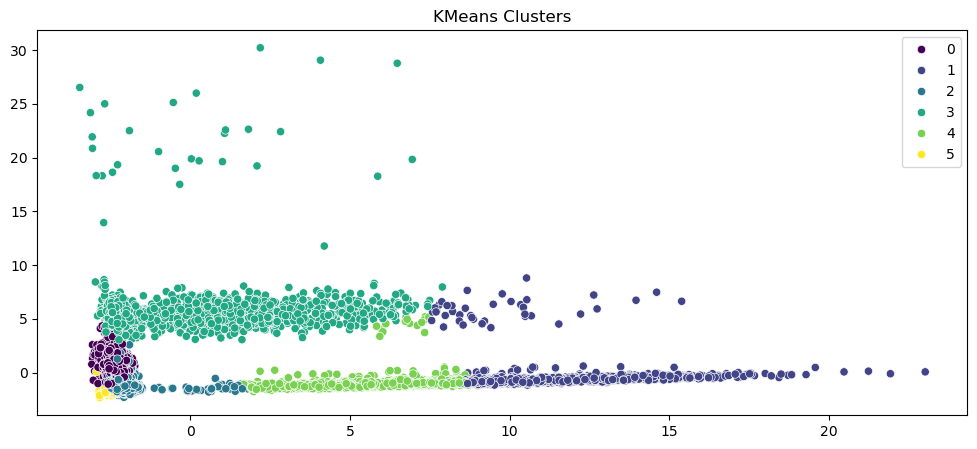

KMeans labels:
kmeans_label
Traveler               6932
Family/Home            3517
Essential spender      1500
Status spender         1461
Tech/Digital native    1267
Foodie/Social           348
Name: count, dtype: int64


In [11]:
# Features
axis3_features = ['pct_supermercado', 'pct_restaurante', 'pct_entretenimiento', 'pct_viajes', 'pct_educacion', 'pct_salud', 'pct_tecnologia', 'pct_servicios_digitales', 'pct_ropa_accesorios', 'pct_transporte', 'pct_hogar', 'avg_ticket_size', 'msi_usage_rate', 'recurring_charge_count']
df_axis3 = df[axis3_features].dropna()
X_axis3 = scaler.fit_transform(df_axis3)

# KMeans (6 clusters)
kmeans3 = KMeans(n_clusters=6, random_state=42)
kmeans_labels3 = kmeans3.fit_predict(X_axis3)
print('KMeans Silhouette:', silhouette_score(X_axis3, kmeans_labels3))

# Visualize
X_pca3 = pca.fit_transform(X_axis3)
plt.figure(figsize=(12,5))
plt.subplot(1,1,1)
sns.scatterplot(x=X_pca3[:,0], y=X_pca3[:,1], hue=kmeans_labels3, palette='viridis')
plt.title('KMeans Clusters')
plt.show()

# Assign labels
cluster_means3 = df_axis3.groupby(kmeans_labels3).mean()
# Spending score: sort by sum of features
spend_score = cluster_means3.sum(axis=1).sort_values()
labels3 = ['Essential spender', 'Foodie/Social', 'Tech/Digital native', 'Traveler', 'Family/Home', 'Status spender']
cluster_to_label3 = {old: new for old, new in zip(spend_score.index, labels3)}
df_axis3['kmeans_label'] = [cluster_to_label3[c] for c in kmeans_labels3]
print('KMeans labels:')
print(df_axis3['kmeans_label'].value_counts())

## Axis 4: Digital Engagement & Loyalty
Expected clusters: Power user, Casual, At-risk, Dormant

KMeans Silhouette: 0.2504180159688207


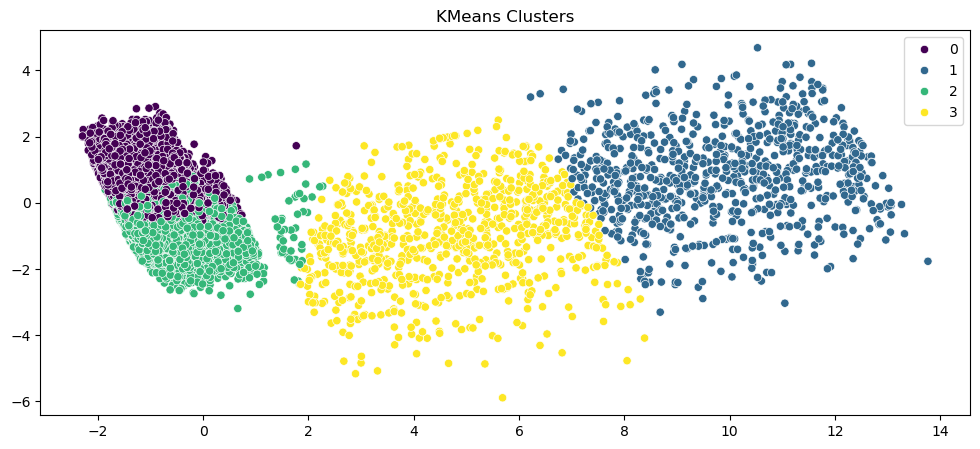

KMeans labels:
kmeans_label
Power user    7125
Casual        5530
At-risk        815
Dormant        804
Name: count, dtype: int64


In [16]:
# Features
axis4_features = ['engagement_score', 'digital_payment_rate', 'cash_dependency', 'antiguedad_dias', 'product_diversity_score', 'dias_desde_ultimo_login']
df_axis4 = df[axis4_features]

# Drop NaN after encoding
df_axis4 = df_axis4.dropna()

# Scale
scaler4 = RobustScaler()
X_axis4 = scaler4.fit_transform(df_axis4)

# KMeans
kmeans4 = KMeans(n_clusters=4, random_state=42)
kmeans_labels4 = kmeans4.fit_predict(X_axis4)
print('KMeans Silhouette:', silhouette_score(X_axis4, kmeans_labels4))

# Visualize
X_pca4 = pca.fit_transform(X_axis4)
plt.figure(figsize=(12,5))
plt.subplot(1,1,1)
sns.scatterplot(x=X_pca4[:,0], y=X_pca4[:,1], hue=kmeans_labels4, palette='viridis')
plt.title('KMeans Clusters')
plt.show()

# Assign labels
cluster_means4 = df_axis4.groupby(kmeans_labels4).mean()
# Risk score: higher values indicate lower engagement (higher risk)
risk_score4 = (-cluster_means4['engagement_score'] - cluster_means4['digital_payment_rate'] + 
               cluster_means4['cash_dependency'] - cluster_means4['antiguedad_dias'] - 
               cluster_means4['product_diversity_score'] + cluster_means4['dias_desde_ultimo_login'])
cluster_risk4 = risk_score4.sort_values()
labels4 = ['Power user', 'Casual', 'At-risk', 'Dormant']
cluster_to_label4 = {old: new for old, new in zip(cluster_risk4.index, labels4)}
df_axis4['kmeans_label'] = [cluster_to_label4[c] for c in kmeans_labels4]
print('KMeans labels:')
print(df_axis4['kmeans_label'].value_counts())

# Clustered dataset

In [17]:
# Create base dataframe with all unique user_ids
base_df = pd.DataFrame({'user_id': df['user_id'].unique()})

# Axis 1: Financial Risk Profile
axis1_df = pd.DataFrame({
    'user_id': df.iloc[df_axis1.index]['user_id'],
    'axis1_kmeans_label': df_axis1['kmeans_label']
})

# Axis 2: Income & Wealth Tier
axis2_df = pd.DataFrame({
    'user_id': df.iloc[df_axis2.index]['user_id'],
    'axis2_kmeans_label': df_axis2['kmeans_label']
})

# Axis 3: Spending Lifestyle
axis3_df = pd.DataFrame({
    'user_id': df.iloc[df_axis3.index]['user_id'],
    'axis3_kmeans_label': df_axis3['kmeans_label']
})

# Axis 4: Digital Engagement & Loyalty
axis4_df = pd.DataFrame({
    'user_id': df.iloc[df_axis4.index]['user_id'],
    'axis4_kmeans_label': df_axis4['kmeans_label']
})

# Merge all axis dataframes
merged_df = base_df.merge(axis1_df, on='user_id', how='left') \
    .merge(axis2_df, on='user_id', how='left') \
    .merge(axis3_df, on='user_id', how='left') \
    .merge(axis4_df, on='user_id', how='left')

# Save to CSV
merged_df.to_csv('user_clusters.csv', index=False)
print(f"user_clusters.csv created with {len(merged_df)} rows")


user_clusters.csv created with 15025 rows
